# Экономика холодного канала в CPA-агентстве

Разбор воронки, которую я вёл сам в течение года в агентстве лидогенерации для автодилеров.
Цифры воронки — реальные, мои. Стоимостная часть построена на допущениях, они помечены явно.

**Вопрос кейса:** может ли холодный обзвон одним человеком быть каналом роста для агентства,
или это тупик? Я год работал внутри этого канала и хочу посчитать, что он давал на самом деле.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(10,5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=.3

# Реальная воронка за 12 месяцев работы
CALLS, TARGET, MEETINGS, DEALS = 1200, 350, 27, 5   # целевых 300-400 -> беру середину, встреч 25-30 -> 27
funnel = pd.DataFrame({
    "этап": ["Звонки", "Целевые разговоры", "Встречи", "Сделки"],
    "штук": [CALLS, TARGET, MEETINGS, DEALS],
})
funnel["конверсия с прошлого этапа"] = (funnel["штук"] / funnel["штук"].shift(1)).round(3)
funnel["конверсия от звонка"] = (funnel["штук"] / CALLS).round(4)
funnel

,этап,штук,конверсия с прошлого этапа,конверсия от звонка
0,Звонки,1200,NaN,1.0000
1,Целевые разговоры,350,0.292,0.2917
2,Встречи,27,0.077,0.0225
3,Сделки,5,0.185,0.0042


## 1. Что показывает воронка

Первое, что бросается в глаза, — не общая конверсия, а то, **на каком этапе теряется больше всего**.

In [2]:
print(f"Звонков на одну сделку:            {CALLS/DEALS:.0f}")
print(f"Звонков на одну встречу:           {CALLS/MEETINGS:.0f}")
print(f"Целевых разговоров на встречу:     {TARGET/MEETINGS:.0f}")
print(f"Встреч на сделку:                  {MEETINGS/DEALS:.1f}")
print(f"Сквозная конверсия звонок -> сделка: {DEALS/CALLS:.2%}")

Звонков на одну сделку:            240
Звонков на одну встречу:           44
Целевых разговоров на встречу:     13
Встреч на сделку:                  5.4
Сквозная конверсия звонок -> сделка: 0.42%


**Узкое место — переход от целевого разговора к встрече: 7.7%.** Из тринадцати человек,
с которыми удалось поговорить по делу, на встречу соглашался один. Это и был главный барьер,
и он совпадает с тем, что я слышал в трубке: «у нас есть подрядчик», «у нас свои маркетологи».

Дальше по воронке всё наоборот неплохо: каждая пятая встреча заканчивалась сделкой.
То есть продукт продавался — проблема была в том, чтобы вообще дойти до разговора.

## 2. Стоимость сделки

Здесь начинаются допущения. Базы я искал сам или покупал дёшево, поэтому прямых расходов
на лид почти не было — основная стоимость канала это моё рабочее время.

Ниже считаю стоимость сделки при разных уровнях ФОТ. **Свою реальную цифру подставь сам** —
я её не знаю и выдумывать не буду.

In [3]:
fot_options = [40_000, 60_000, 80_000, 100_000]
rows=[]
for fot in fot_options:
    year = fot*12
    rows.append({"ФОТ в месяц, ₽": fot, "Год, ₽": year,
                 "Стоимость сделки, ₽": round(year/DEALS),
                 "Стоимость встречи, ₽": round(year/MEETINGS),
                 "Стоимость звонка, ₽": round(year/CALLS,1)})
cost = pd.DataFrame(rows); cost

,"ФОТ в месяц, ₽","Год, ₽","Стоимость сделки, ₽","Стоимость встречи, ₽","Стоимость звонка, ₽"
0,40000,480000,96000,17778,400.0
1,60000,720000,144000,26667,600.0
2,80000,960000,192000,35556,800.0
3,100000,1200000,240000,44444,1000.0


Даже при скромном ФОТ одна сделка обходится в сотни тысяч рублей. Для сравнения: агентство
продавало лиды клиенту от 30 ₽ за штуку, а работало за процент от рекламного бюджета или
по оплате за звонки. Чтобы канал окупился, средний контракт должен покрывать эту стоимость
привлечения с запасом — а контракты были месячные, с продлением по факту результата.

## 3. Сколько звонков нужно для плана

Если считать воронку стабильной, требуемый объём звонков линейно растёт с планом по сделкам.
Вопрос: реалистично ли это для одного человека.

In [4]:
plan = np.arange(5, 31, 5)
need_calls = plan * (CALLS/DEALS)
need_per_month = need_calls/12
need_per_workday = need_per_month/21

plan_df = pd.DataFrame({"сделок в год": plan,
                        "звонков в год": need_calls.round(),
                        "звонков в месяц": need_per_month.round(),
                        "звонков в рабочий день": need_per_workday.round(1)})
plan_df

,сделок в год,звонков в год,звонков в месяц,звонков в рабочий день
0,5,1200.0,100.0,4.8
1,10,2400.0,200.0,9.5
2,15,3600.0,300.0,14.3
3,20,4800.0,400.0,19.0
4,25,6000.0,500.0,23.8
5,30,7200.0,600.0,28.6


## 4. Что эффективнее: звонить больше или конвертировать лучше

Оба рычага линейны по числу сделок, поэтому сравниваю их не в процентах, а в достижимости:
насколько надо сдвинуть каждый, чтобы получить одинаковый прирост.

In [5]:
base_deals = DEALS
scenarios = {
    "как есть": (CALLS, TARGET/CALLS, MEETINGS/TARGET, DEALS/MEETINGS),
    "звонков +50%": (CALLS*1.5, TARGET/CALLS, MEETINGS/TARGET, DEALS/MEETINGS),
    "конверсия в встречу 7.7% -> 12%": (CALLS, TARGET/CALLS, 0.12, DEALS/MEETINGS),
    "конверсия в встречу 7.7% -> 15%": (CALLS, TARGET/CALLS, 0.15, DEALS/MEETINGS),
    "оба рычага": (CALLS*1.5, TARGET/CALLS, 0.12, DEALS/MEETINGS),
}
res = {k: c*t*m*d for k,(c,t,m,d) in scenarios.items()}
sc = pd.DataFrame({"сделок в год": pd.Series(res).round(1)})
sc["к базе"] = (sc["сделок в год"]/base_deals).round(2)
sc

,сделок в год,к базе
как есть,5.0,1.00
звонков +50%,7.5,1.50
конверсия в встречу 7.7% -> 12%,7.8,1.56
конверсия в встречу 7.7% -> 15%,9.7,1.94
оба рычага,11.7,2.34


## 5. Графики

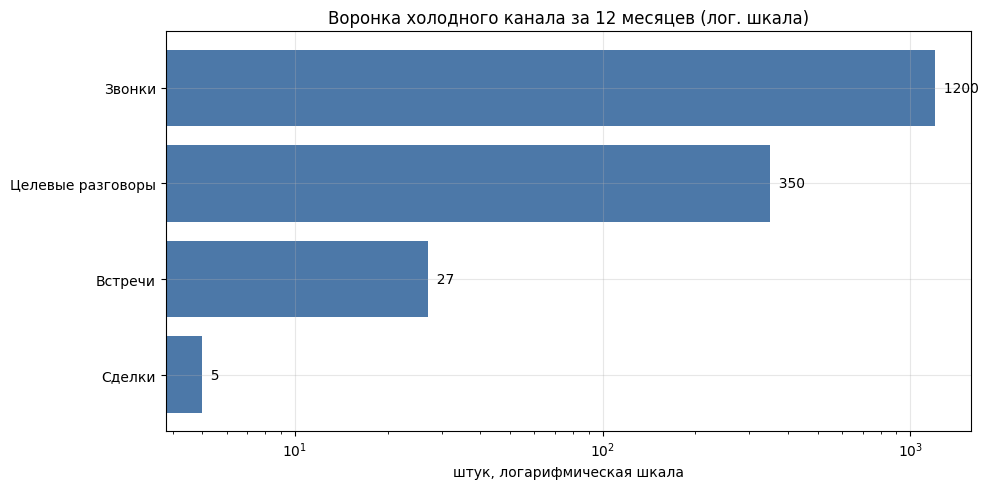

In [6]:
fig, ax = plt.subplots()
ax.barh(funnel["этап"][::-1], funnel["штук"][::-1], color="#4C78A8")
for i,(s,v) in enumerate(zip(funnel["этап"][::-1], funnel["штук"][::-1])):
    ax.text(v, i, f"  {v}", va="center")
ax.set_xscale("log"); ax.set_title("Воронка холодного канала за 12 месяцев (лог. шкала)")
ax.set_xlabel("штук, логарифмическая шкала")
plt.tight_layout(); plt.savefig("/Users/egor/Desktop/portfolio/analytics-portfolio/04-lead-economics/charts/1_funnel.png", dpi=120); plt.show()

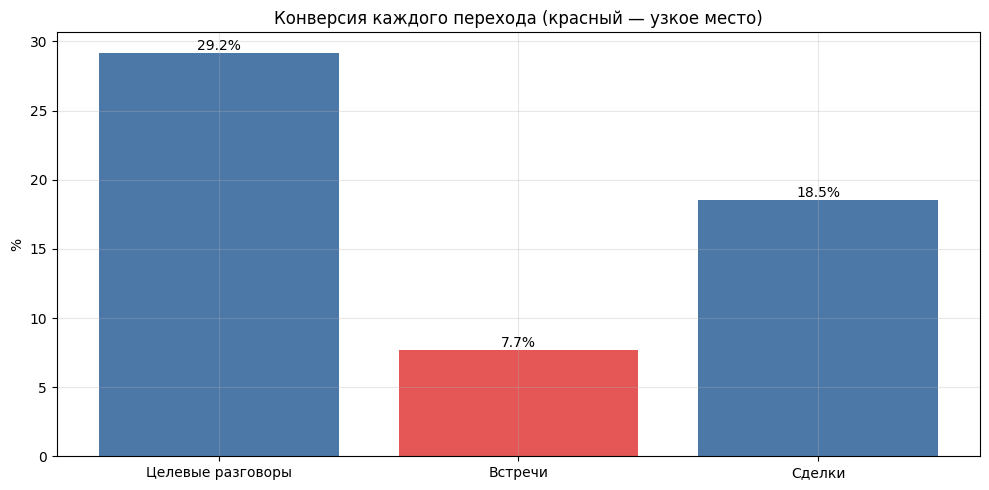

In [7]:
step = funnel.dropna(subset=["конверсия с прошлого этапа"])
ax = plt.subplots()[1]
bars = ax.bar(step["этап"], step["конверсия с прошлого этапа"]*100, color=["#4C78A8","#E45756","#4C78A8"])
for b,v in zip(bars, step["конверсия с прошлого этапа"]*100):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}%", ha="center", va="bottom")
ax.set_title("Конверсия каждого перехода (красный — узкое место)")
ax.set_ylabel("%")
plt.tight_layout(); plt.savefig("/Users/egor/Desktop/portfolio/analytics-portfolio/04-lead-economics/charts/2_step_conversion.png", dpi=120); plt.show()

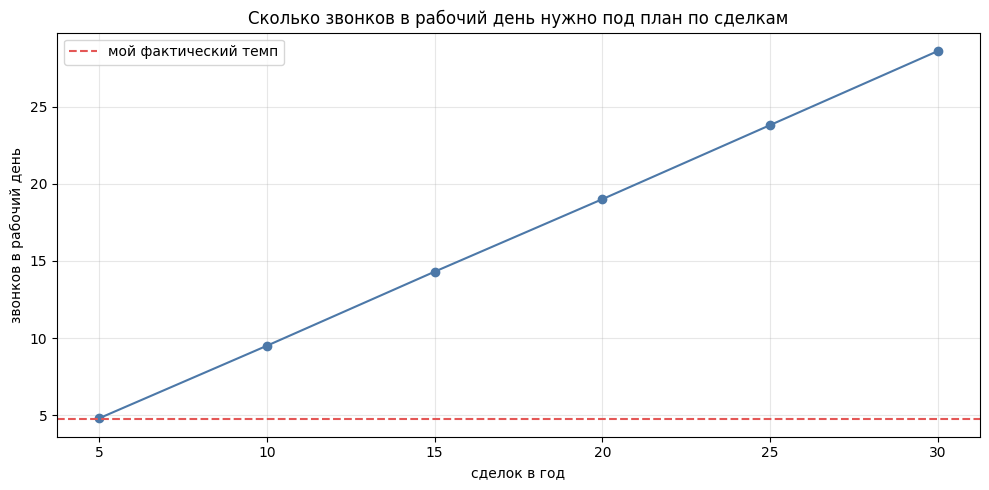

In [8]:
ax = plt.subplots()[1]
ax.plot(plan_df["сделок в год"], plan_df["звонков в рабочий день"], marker="o", color="#4C78A8")
ax.axhline(1200/12/21, color="#E45756", ls="--", label="мой фактический темп")
ax.set_title("Сколько звонков в рабочий день нужно под план по сделкам")
ax.set_xlabel("сделок в год"); ax.set_ylabel("звонков в рабочий день"); ax.legend()
plt.tight_layout(); plt.savefig("/Users/egor/Desktop/portfolio/analytics-portfolio/04-lead-economics/charts/3_calls_needed.png", dpi=120); plt.show()

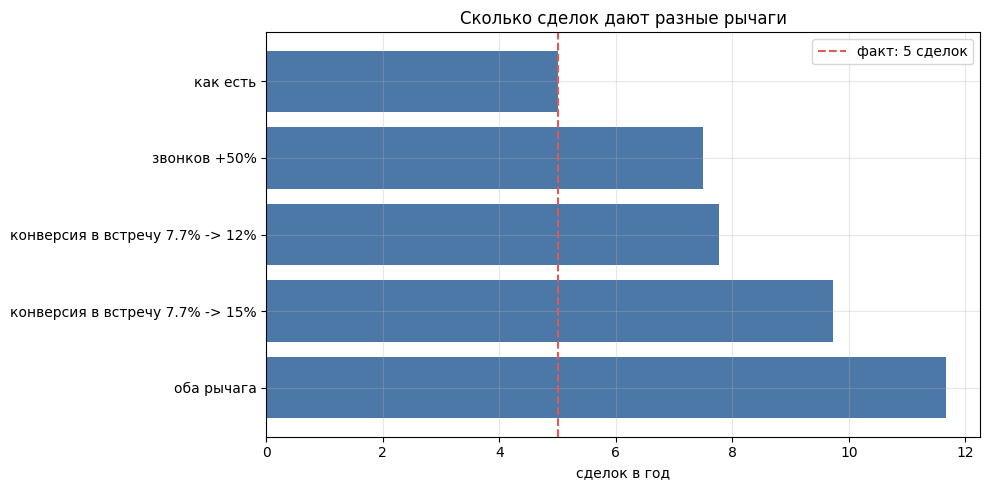

In [9]:
ax = plt.subplots()[1]
ax.barh(list(res.keys())[::-1], list(res.values())[::-1], color="#4C78A8")
ax.axvline(DEALS, color="#E45756", ls="--", label="факт: 5 сделок")
ax.set_title("Сколько сделок дают разные рычаги"); ax.set_xlabel("сделок в год"); ax.legend()
plt.tight_layout(); plt.savefig("/Users/egor/Desktop/portfolio/analytics-portfolio/04-lead-economics/charts/4_levers.png", dpi=120); plt.show()

## Выводы

- **Узкое место — не продукт, а вход в разговор.** Встреча превращалась в сделку в 18.5%
  случаев, а целевой разговор во встречу — только в 7.7%. Продукт продавался тем, кто
  соглашался посмотреть; проблема была дойти до этого этапа.
- **Канал не масштабируется одним человеком.** При фактической воронке на 20 сделок в год
  нужно около 19 звонков в рабочий день без единого пропуска, и это только набор номера,
  без встреч, подготовки и ведения текущих клиентов. Мой фактический темп был около
  пяти звонков в день, и он уже съедал рабочий день целиком.
- **Рычаг конверсии сильнее рычага объёма.** Поднять конверсию в встречу с 7.7% до 12% даёт
  тот же прирост, что и рост числа звонков в полтора раза, но не требует ещё одного человека
  в штате. Именно поэтому я переписывал скрипт по записям своих же разговоров, а не пытался
  просто звонить больше.
- **Стоимость сделки — сотни тысяч рублей при любом разумном ФОТ.** На рынке, где клиент
  подписывается на месяц с продлением по результату, такой канал окупается только при
  длинном LTV клиента. Проверить это на своих данных я не мог — до нужного числа сделок
  канал не дожил.

## Ограничения

- Воронка построена по моему собственному учёту за год: часть периода я вёл клиентов в Excel,
  потом перенёс в CRM. Это ручной учёт одного человека, не выгрузка из системы.
- Числа целевых разговоров и встреч я помню диапазоном (300–400 и 25–30) и беру середину.
- Стоимостная часть — допущения по ФОТ, не фактические цифры.
- Один год, один человек, один рынок в кризис. Переносить эти конверсии на другие ниши нельзя.